In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the neural network
model = Sequential([
    Dense(2, activation='relu', input_shape=(2,)),
    Dense(1, activation='linear')
])

# Manually set the weights and biases
W_hidden = np.array([[1, 1], [1, 1]])
c_hidden = np.array([0, -1])
W_output = np.array([[1], [-2]])
b_output = np.array([0])

# Assign weights to layers
model.layers[0].set_weights([W_hidden, c_hidden])
model.layers[1].set_weights([W_output, b_output])

# Test the neural network
XOR_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
outputs = model.predict(XOR_inputs)

for x, y in zip(XOR_inputs, outputs):
    print(f"Input: {x}, Output: {y}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
Input: [0 0], Output: [0.]
Input: [0 1], Output: [1.]
Input: [1 0], Output: [1.]
Input: [1 1], Output: [0.]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
Input: [0 0], Output: [0.]
Input: [0 1], Output: [1.]
Input: [1 0], Output: [1.]
Input: [1 1], Output: [0.]
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


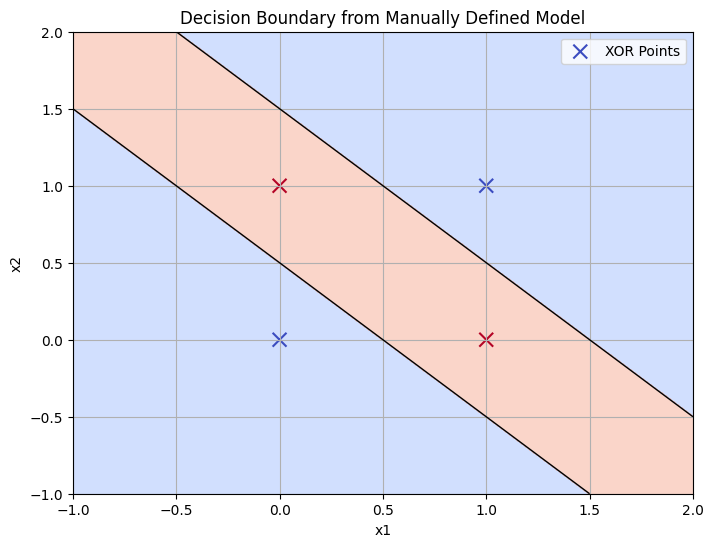

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Define the neural network
model = Sequential([
    Dense(2, activation='relu', input_shape=(2,)),
    Dense(1, activation='linear')
])

# Manually set the weights and biases
W_hidden = np.array([[1, 1], [1, 1]])
c_hidden = np.array([0, -1])
W_output = np.array([[1], [-2]])
b_output = np.array([0])

# Assign weights to layers
model.layers[0].set_weights([W_hidden, c_hidden])
model.layers[1].set_weights([W_output, b_output])

# Test the neural network
XOR_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
outputs = model.predict(XOR_inputs)

for x, y in zip(XOR_inputs, outputs):
    print(f"Input: {x}, Output: {y}")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds = model.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, preds > 0.5, alpha=0.4, cmap='coolwarm')
plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=1)

# Optional: Plot validation points
plt.scatter(XOR_inputs[:, 0], XOR_inputs[:, 1], c=[0,1,1,0], cmap='coolwarm', marker='x', s=100, label='XOR Points')

plt.title("Decision Boundary from Manually Defined Model")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Define the neural network
model = Sequential([
    Dense(2, activation='relu', input_shape=(2,)),
    Dense(1, activation='linear')
])

# Manually set the weights and biases
W_hidden = np.array([[1, 1], [1, 1]])
c_hidden = np.array([0, -1])
W_output = np.array([[1], [-2]])
b_output = np.array([0])

# Assign weights to layers
model.layers[0].set_weights([W_hidden, c_hidden])
model.layers[1].set_weights([W_output, b_output])

# Test the neural network
XOR_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
outputs = model.predict(XOR_inputs)

for x, y in zip(XOR_inputs, outputs):
    print(f"Input: {x}, Output: {y}")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds = model.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, preds > 0.5, alpha=0.4, cmap='coolwarm')
plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=1)

# Optional: Plot validation points
plt.scatter(XOR_inputs[:, 0], XOR_inputs[:, 1], c=[0,1,1,0], cmap='coolwarm', marker='x', s=100, label='XOR Points')

plt.title("Decision Boundary from Manually Defined Model")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# XOR data
XOR_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
XOR_outputs = np.array([[0], [1], [1], [0]])

# Define model
model = Sequential([
    Dense(4, activation="tanh", input_shape=(2,)),
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.01), loss='binary_crossentropy')

# Train
model.fit(XOR_inputs, XOR_outputs, epochs=1000, verbose=0)

# Predictions
outputs = model.predict(XOR_inputs, verbose=0)

# Show results
print("\nPredictions (p > 0.5 → 1):")
for x, y in zip(XOR_inputs, outputs):
    prob = y[0]
    pred = 1 if prob > 0.5 else 0
    print(f"Input: {x}, Prob: {prob:.4f}, Predicted: {pred}")


Predictions (p > 0.5 → 1):
Input: [0 0], Prob: 0.0015, Predicted: 0
Input: [0 1], Prob: 0.4992, Predicted: 0
Input: [1 0], Prob: 0.9980, Predicted: 1
Input: [1 1], Prob: 0.5012, Predicted: 1


gaussian approach

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# Centers for the 4 XOR inputs
means = {
    '00': np.array([0, 0]),
    '01': np.array([0, 1]),
    '10': np.array([1, 0]),
    '11': np.array([1, 1])
}

# All Gaussians share the same identity covariance
cov = np.eye(2)

# Create multivariate normal distributions
dists = {
    '00': multivariate_normal(mean=means['00'], cov=cov),
    '01': multivariate_normal(mean=means['01'], cov=cov),
    '10': multivariate_normal(mean=means['10'], cov=cov),
    '11': multivariate_normal(mean=means['11'], cov=cov)
}

# Map distribution to XOR output
dist_class_map = {
    '00': 0,
    '01': 1,
    '10': 1,
    '11': 0
}

In [ ]:
def classify(x):
    # Compute probabilities under each distribution
    probs = {k: dist.pdf(x) for k, dist in dists.items()}

    # Choose the distribution with highest likelihood
    best = max(probs, key=probs.get)

    return dist_class_map[best], probs

In [ ]:
inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

print("Generative model predictions:")
for x in inputs:
    y_pred, probs = classify(x)
    print(f"Input: {x}, Predicted: {y_pred}, Probs: {probs}")

Generative model predictions:
Input: [0 0], Predicted: 0, Probs: {'00': np.float64(0.15915494309189535), '01': np.float64(0.09653235263005391), '10': np.float64(0.09653235263005391), '11': np.float64(0.05854983152431917)}
Input: [0 1], Predicted: 1, Probs: {'00': np.float64(0.09653235263005391), '01': np.float64(0.15915494309189535), '10': np.float64(0.05854983152431917), '11': np.float64(0.09653235263005391)}
Input: [1 0], Predicted: 1, Probs: {'00': np.float64(0.09653235263005391), '01': np.float64(0.05854983152431917), '10': np.float64(0.15915494309189535), '11': np.float64(0.09653235263005391)}
Input: [1 1], Predicted: 0, Probs: {'00': np.float64(0.05854983152431917), '01': np.float64(0.09653235263005391), '10': np.float64(0.09653235263005391), '11': np.float64(0.15915494309189535)}


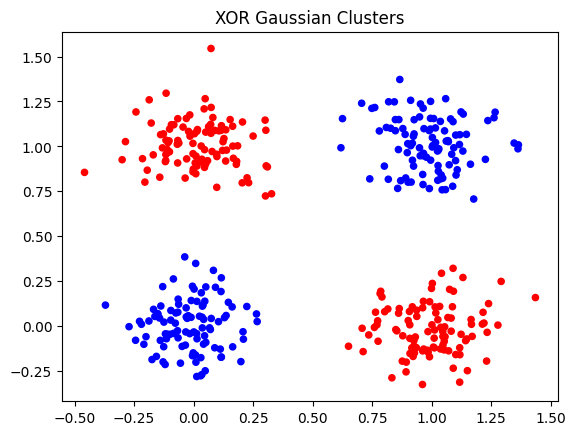

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Means
means = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
labels = np.array([0, 1, 1, 0])

# Generate data points around each mean
np.random.seed(42)
X = []
y = []

for i in range(4):
    X.append(np.random.multivariate_normal(mean=means[i], cov=0.02 * np.eye(2), size=100))
    y.append(np.full(100, labels[i]))

X = np.vstack(X)
y = np.hstack(y)

# Optional: Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=20)
plt.title("XOR Gaussian Clusters")
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback

# XOR validation set
X_val = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_val = np.array([0, 1, 1, 0])

# Training data: Gaussian blobs around XOR points
X = np.concatenate([
    np.random.multivariate_normal([0, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([0, 1], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 1], 0.01 * np.eye(2), 100)
])
y = np.array([0]*100 + [1]*100 + [1]*100 + [0]*100)

# Custom callback: stop when val accuracy reaches 100%
class StopAtValAccuracy(Callback):
    def __init__(self, target=1.0):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        # Compute validation predictions manually
        val_preds = self.model.predict(X_val)
        val_classes = (val_preds > 0.5).astype(int).flatten()
        acc = np.mean(val_classes == y_val)
        print(f"Custom Val Accuracy: {acc*100:.2f}%")
        if acc >= self.target:
            print(f"\nReached {self.target*100:.0f}% validation accuracy. Stopping training.")
            self.model.stop_training = True

# Define the model (with linear output)
model = Sequential([
    Dense(4, input_shape=(2,), activation='relu'),
     Dense(4, activation='relu') ,
    Dense(1, activation='linear')  # ← linear output here
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train the model
model.fit(
    X, y,
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[StopAtValAccuracy()]
)

# Predict on XOR
print("\nPredictions on XOR validation set:")
preds = model.predict(X_val)
for x, p in zip(X_val, preds):
    print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}")

# Print model weights
for i, layer in enumerate(model.layers):
    weights, biases = layer.get_weights()
    print(f"\nLayer {i+1} weights:\n{weights}")
    print(f"Layer {i+1} biases:\n{biases}")

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Custom Val Accuracy: 50.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8734  
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Custom Val Accuracy: 50.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3162 
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Custom Val Accuracy: 75.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2423 
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Custom Val Accuracy: 100.00%

Reached 100% validation accuracy. Stopping training.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2310 

Predictions on XOR validation set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Input: [0 0], Output: 0.4211, Predicted Class: 0
Input: [0 1], Output: 0.5400, Predicted Class: 1
Input: [1 0], Output: 0.5276, Predicted Class: 1
Input: [1 1], Output: 0.4708, Predicted Class: 0

Layer 1 weights:
[[ 0.58103    -0.5703839   0.31162995 -0.32021227]
 [ 0.09708419  0.7266868   0.8096544   0.10576779]]
Layer 1 biases:
[

<ipython-input-2-482334101abd>:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}")


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Custom Val Accuracy: 50.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2843
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Custom Val Accuracy: 75.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1927 
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Custom Val Accuracy: 100.00%

Reached 100% validation accuracy. Stopping training.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1404  

Predictions on XOR validation set:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Input: [0 0], Output: 0.2228, Predicted Class: 0
Input: [0 1], Output: 0.9538, Predicted Class: 1
Input: [1 0], Output: 0.5860, Predicted Class: 1
Input: [1 1], Output: 0.3742, Predicted Class: 0

Layer 1 weights:
[[-0.553894   -0.42444456 -0.5242938   0.22608158]
 [ 0.4169308  -0.43793938  0.92768097  0.20884983]]
Layer 1 biases:
[0.07020833 0.23965459 0.2582547  0.11737508]

Layer 2 weights:
[[-0.4352669  -0.2849133   0.89807355  0.18756293]
 [ 0.3914253   0.10

<ipython-input-9-d66e9b5a5698>:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}")


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 638us/step


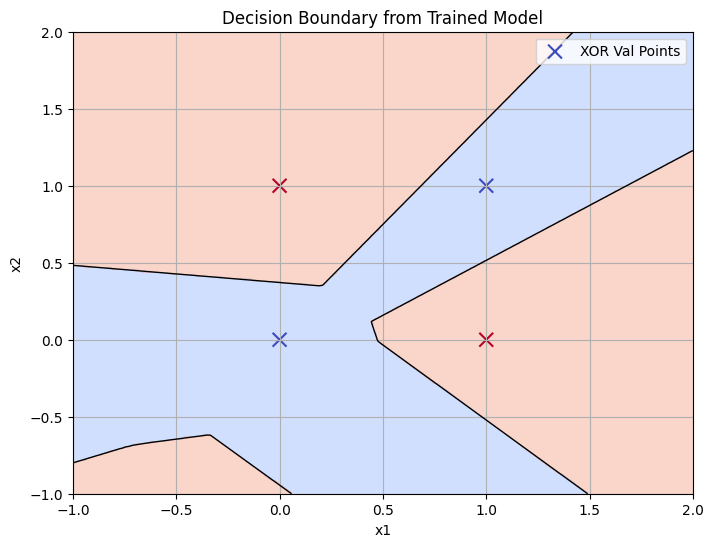

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt

# XOR validation set
X_val = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_val = np.array([0, 1, 1, 0])

# Training data: Gaussian blobs around XOR points
X = np.concatenate([
    np.random.multivariate_normal([0, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([0, 1], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 1], 0.01 * np.eye(2), 100)
])
y = np.array([0]*100 + [1]*100 + [1]*100 + [0]*100)

# Custom callback: stop when val accuracy reaches 100%
class StopAtValAccuracy(Callback):
    def __init__(self, target=1.0):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        # Compute validation predictions manually
        val_preds = self.model.predict(X_val)
        val_classes = (val_preds > 0.5).astype(int).flatten()
        acc = np.mean(val_classes == y_val)
        print(f"Custom Val Accuracy: {acc*100:.2f}%")
        if acc >= self.target:
            print(f"\nReached {self.target*100:.0f}% validation accuracy. Stopping training.")
            self.model.stop_training = True

# Define the model (with linear output)
model = Sequential([
    Dense(4, input_shape=(2,), activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='linear')  # ← linear output here
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train the model
model.fit(
    X, y,
    epochs=1000,
    batch_size=32,
    verbose=1,
    callbacks=[StopAtValAccuracy()]
)

# Predict on XOR
print("\nPredictions on XOR validation set:")
preds = model.predict(X_val)
for x, p in zip(X_val, preds):
    print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}")

# Print model weights
for i, layer in enumerate(model.layers):
    weights, biases = layer.get_weights()
    print(f"\nLayer {i+1} weights:\n{weights}")
    print(f"Layer {i+1} biases:\n{biases}")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds = model.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, preds > 0.5, alpha=0.4, cmap='coolwarm')
plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=1)

# Optional: Plot validation points
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='coolwarm', marker='x', s=100, label='XOR Val Points')

plt.title("Decision Boundary from Trained Model")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

In [ ]:

# --- Data Preparation ---
# XOR validation set
X_val = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y_val = np.array([0, 1, 1, 0])

# Training data: Gaussian blobs around XOR points
X = np.concatenate([
    np.random.multivariate_normal([0, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([0, 1], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 1], 0.01 * np.eye(2), 100)
])
y = np.array([0]*100 + [1]*100 + [1]*100 + [0]*100)

Epoch 1/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Custom Val Accuracy: 50.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.4822
Epoch 2/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Custom Val Accuracy: 25.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.2939 
Epoch 3/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Custom Val Accuracy: 75.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2643 
Epoch 4/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Custom Val Accuracy: 25.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2596 
Epoch 5/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Custom Val Accuracy: 50.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2490 
Epoch 6/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Custom Val Accuracy: 75.00%
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2330 
Epoch 7/250
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Custom Val Accuracy: 100.00%

Reached 100% validation accuracy. Stopping training.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2214 

Predictions

<ipython-input-25-f7af09f9ea01>:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}")


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


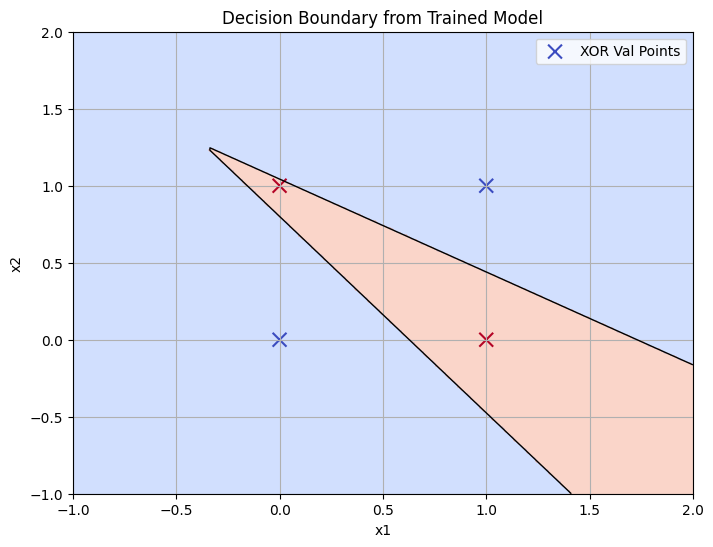

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
import matplotlib.pyplot as plt


# --- Model Definition and Training ---
# Custom callback: stop when val accuracy reaches 100%
class StopAtValAccuracy(Callback):
    def __init__(self, target=1.0):
        super().__init__()
        self.target = target

    def on_epoch_end(self, epoch, logs=None):
        val_preds = self.model.predict(X_val)
        val_classes = (val_preds > 0.5).astype(int).flatten()
        acc = np.mean(val_classes == y_val)
        print(f"Custom Val Accuracy: {acc*100:.2f}%")
        if acc >= self.target:
            print(f"\nReached {self.target*100:.0f}% validation accuracy. Stopping training.")
            self.model.stop_training = True

# Define the model (with linear output)
model = Sequential([
    Dense(2, input_shape=(2,), activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train the model
model.fit(
    X, y,
    epochs=250,
    batch_size=32,
    verbose=1,
    callbacks=[StopAtValAccuracy()]
)

# --- Model Evaluation and Saving ---
# Predict on XOR
print("\nPredictions on XOR validation set:")
preds = model.predict(X_val)
for x, p in zip(X_val, preds):
    print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}")

# Print model weights
for i, layer in enumerate(model.layers):
    weights, biases = layer.get_weights()
    print(f"\nLayer {i+1} weights:\n{weights}")
    print(f"Layer {i+1} biases:\n{biases}")

model.save_weights("xor_linear_model.weights.h5")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds = model.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, preds > 0.5, alpha=0.4, cmap='coolwarm')
plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=1)

# Optional: Plot validation points
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='coolwarm', marker='x', s=100, label='XOR Val Points')

plt.title("Decision Boundary from Trained Model")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Training data: Gaussian blobs around XOR points
X = np.concatenate([
    np.random.multivariate_normal([0, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([0, 1], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 1], 0.01 * np.eye(2), 100)
])
y = np.array([0]*100 + [1]*100 + [1]*100 + [0]*100)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the model (with linear output)
model = Sequential([
    Dense(4, input_shape=(2,), activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='linear')  # linear output
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')

# Train the model
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=1,
    validation_data=(X_val, y_val)
)

# Predict on validation set
print("\nPredictions on validation set:")
preds = model.predict(X_val)
for x, p, actual in zip(X_val, preds, y_val):
    print(f"Input: {x}, Output: {p[0]:.4f}, Predicted Class: {int(p > 0.5)}, Actual: {actual}")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds = model.predict(grid).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, preds > 0.5, alpha=0.4, cmap='coolwarm')
plt.contour(xx, yy, preds, levels=[0.5], colors='black', linewidths=1)

# Optional: Plot validation points
plt.scatter(X_val[:, 0], X_val[:, 1], c=y_val, cmap='coolwarm', marker='x', s=100, label='Validation Points')

plt.title("Decision Boundary from Trained Model")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

Epoch 1/100


ValueError: Dimensions must be equal, but are 32 and 2 for '{{node compile_loss/mse/sub}} = Sub[T=DT_FLOAT](compile_loss/mse/Cast, sequential_11_1/dense_31_1/Relu)' with input shapes: [32], [32,2].

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7038 - loss: 0.6882 - val_accuracy: 0.7500 - val_loss: 0.6279
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6257 - loss: 0.6462 - val_accuracy: 0.5375 - val_loss: 0.5655
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5876 - loss: 0.6057 - val_accuracy: 0.7625 - val_loss: 0.5108
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7276 - loss: 0.5494 - val_accuracy: 0.7750 - val_loss: 0.4761
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7407 - loss: 0.5411 - val_accuracy: 0.7750 - val_loss: 0.4581
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7571 - loss: 0.4910 - val_accuracy: 0.7750 - val_loss: 0.4472
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7523 - loss: 0.4962 - val_accuracy: 0.7750 - val_loss: 0.4404
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7606 - loss: 0.4773 - val_accuracy: 0.7750 -

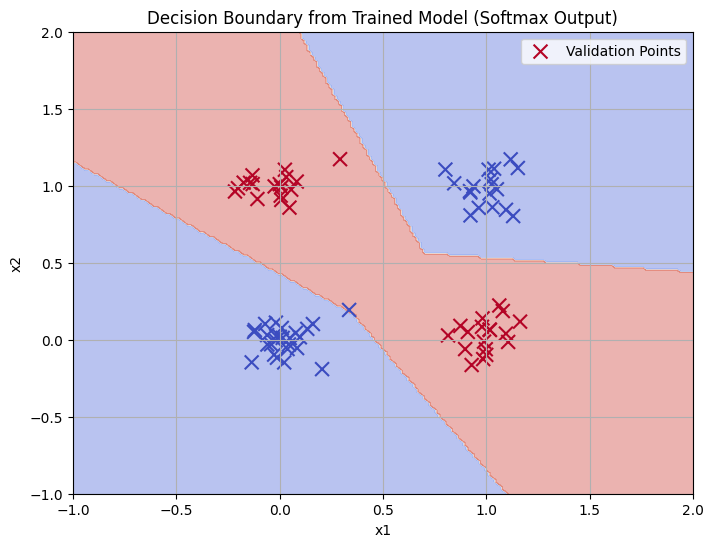

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Training data: Gaussian blobs around XOR points
X = np.concatenate([
    np.random.multivariate_normal([0, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([0, 1], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 1], 0.01 * np.eye(2), 100)
])
y = np.array([0]*100 + [1]*100 + [1]*100 + [0]*100)

# Convert y to one-hot encoded vectors
y_one_hot = np.array([[1, 0] if label == 0 else [0, 1] for label in y])

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# Define the model (with softmax output)
model = Sequential([
    Dense(4, input_shape=(2,), activation='relu'),
    Dense(4, activation='relu'),
    Dense(2, activation='softmax')  # softmax output for 2 classes
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=1,
    validation_data=(X_val, y_val)
)

# Predict on validation set
print("\nPredictions on validation set:")
preds = model.predict(X_val)
predicted_classes = np.argmax(preds, axis=1)
actual_classes = np.argmax(y_val, axis=1)

for x, p, actual in zip(X_val, predicted_classes, actual_classes):
    print(f"Input: {x}, Predicted Class: {p}, Actual: {actual}")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds_grid = model.predict(grid)
predicted_classes_grid = np.argmax(preds_grid, axis=1).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, predicted_classes_grid, alpha=0.4, cmap='coolwarm')

# Optional: Plot validation points
actual_classes_val = np.argmax(y_val, axis=1)
plt.scatter(X_val[:, 0], X_val[:, 1], c=actual_classes_val, cmap='coolwarm', marker='x', s=100, label='Validation Points')

plt.title("Decision Boundary from Trained Model (Softmax Output)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.4777 - mae: 0.5672 - val_loss: 0.3366 - val_mae: 0.5078
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3342 - mae: 0.5202 - val_loss: 0.2849 - val_mae: 0.4972
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2822 - mae: 0.4971 - val_loss: 0.2687 - val_mae: 0.4903
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2719 - mae: 0.4944 - val_loss: 0.2574 - val_mae: 0.4847
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2612 - mae: 0.4893 - val_loss: 0.2491 - val_mae: 0.4784
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2571 - mae: 0.4885 - val_loss: 0.2416 - val_mae: 0.4720
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2489 - mae: 0.4814 - val_loss: 0.2380 - val_mae: 0.4691
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2472 - mae: 0.4803 - val_loss: 0.2314 - val_mae: 0.4644
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.24

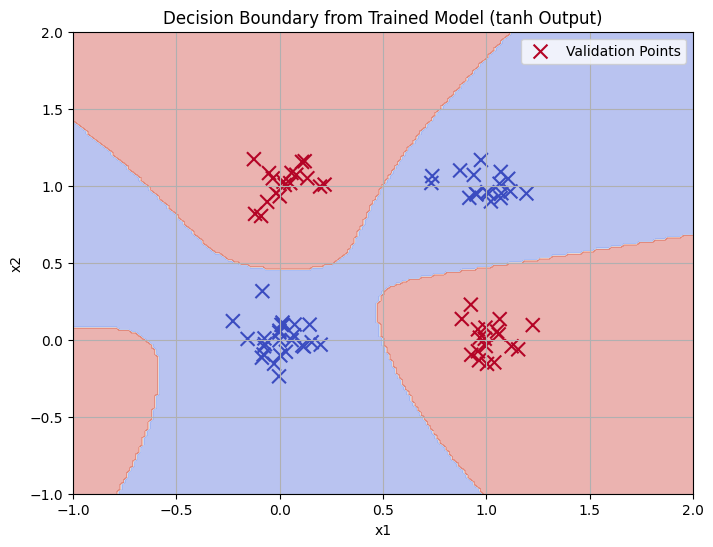

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Training data: Gaussian blobs around XOR points
X = np.concatenate([
    np.random.multivariate_normal([0, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([0, 1], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 0], 0.01 * np.eye(2), 100),
    np.random.multivariate_normal([1, 1], 0.01 * np.eye(2), 100)
])
y = np.array([0]*100 + [1]*100 + [1]*100 + [0]*100)

# Convert y to one-hot encoded vectors
y_one_hot = np.array([[1, 0] if label == 0 else [0, 1] for label in y])

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y_one_hot, test_size=0.2, random_state=42)

# Define the model with relu output
model = Sequential([
    Dense(4, input_shape=(2,), activation='tanh'),
    Dense(2, activation='tanh')  # relu output for 2 outputs
])

model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae']) #MSE is suitable for regression like output

# Train the model
model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=1,
    validation_data=(X_val, y_val)
)

# Predict on validation set
print("\nPredictions on validation set:")
preds = model.predict(X_val)

for x, p, actual in zip(X_val, preds, y_val):
    print(f"Input: {x}, Predicted: {p}, Actual: {actual}")

# --- Plotting Decision Boundary ---

# Create a mesh grid over the input space
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

# Use the model to predict on the grid
preds_grid = model.predict(grid)
#This portion is tricky, because Relu can output any positive number.
#We will check which output is greater and use that as class.
predicted_classes_grid = np.argmax(preds_grid, axis=1).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, predicted_classes_grid, alpha=0.4, cmap='coolwarm')

# Optional: Plot validation points
actual_classes_val = np.argmax(y_val, axis=1)
plt.scatter(X_val[:, 0], X_val[:, 1], c=actual_classes_val, cmap='coolwarm', marker='x', s=100, label='Validation Points')

plt.title("Decision Boundary from Trained Model (tanh Output)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.xlim([-1, 2])
plt.ylim([-1, 2])
plt.show()

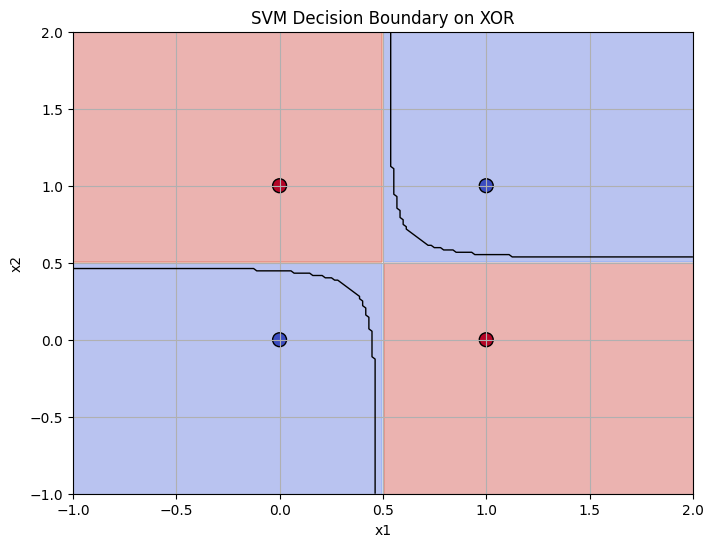

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])

# Train SVM with RBF kernel
clf = SVC(kernel='rbf', C=1.0, gamma='auto', probability=True)
clf.fit(X, y)

# Grid for visualization
xx, yy = np.meshgrid(np.linspace(-1, 2, 200), np.linspace(-1, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid).reshape(xx.shape)
Z_prob = clf.predict_proba(grid)[:, 1].reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.contour(xx, yy, Z_prob, levels=[0.5], colors='black', linewidths=1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=100)
plt.title("SVM Decision Boundary on XOR")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

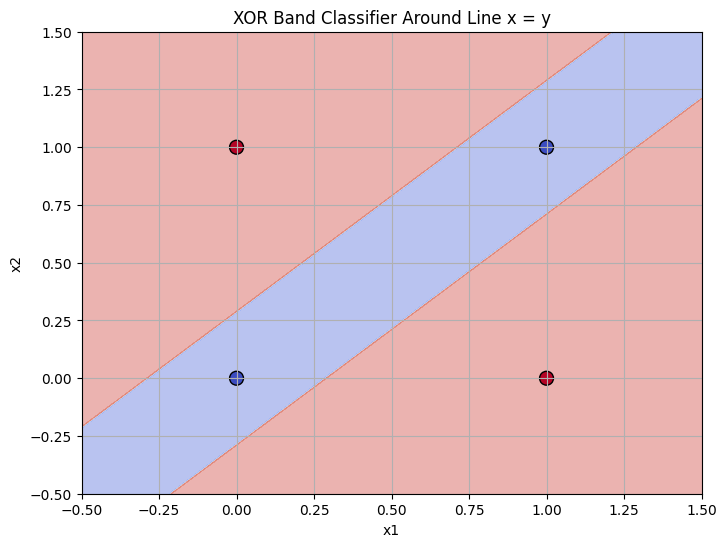

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# XOR data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 0])

# Define margin width
margin_width = 0.2  # tweak this for thickness

# Decision rule: distance from x = y line
def band_classifier(x, margin=0.2):
    # Distance from line x = y is abs(x - y) / sqrt(2), compare with margin
    dist = np.abs(x[:, 0] - x[:, 1]) / np.sqrt(2)
    return (dist > margin).astype(int)  # outside the band → class 1

# Generate grid for visualization
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = band_classifier(grid, margin=margin_width).reshape(xx.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=100)
plt.title("XOR Band Classifier Around Line x = y")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

Predictions: [0. 1. 1. 0.]
True Labels: [0. 1. 1. 0.]

✅ Accuracy: 100.00%


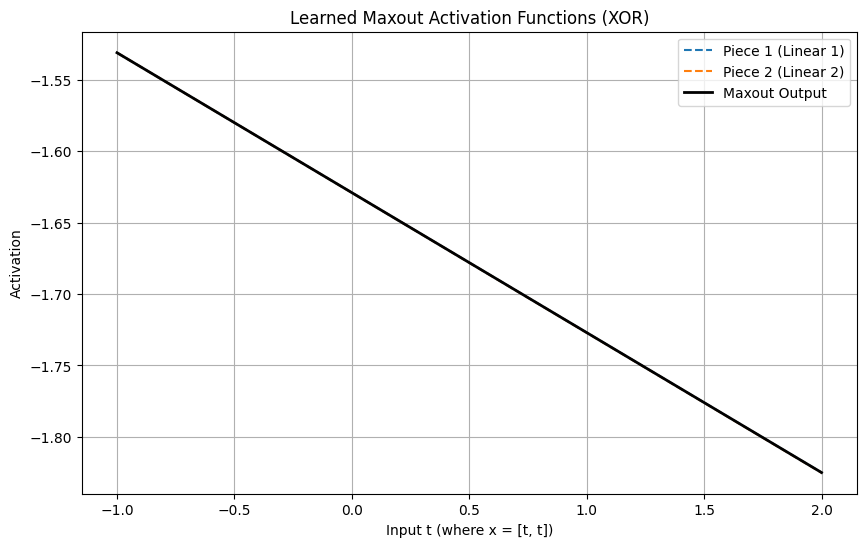

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# XOR data
x = torch.tensor([[0,0],[0,1],[1,0],[1,1]], dtype=torch.float32)
y = torch.tensor([[0],[1],[1],[0]], dtype=torch.float32)

# Maxout layer
class Maxout(nn.Module):
    def __init__(self, in_features, out_features, k):
        super(Maxout, self).__init__()
        self.k = k
        self.lin = nn.Linear(in_features, out_features * k)

    def forward(self, x):
        batch_size = x.size(0)
        out = self.lin(x)
        out = out.view(batch_size, -1, self.k)
        return out.max(dim=2).values

# Model with Maxout hidden layer
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.maxout = Maxout(2, 1, k=2)  # One Maxout unit with 2 pieces
        self.output = nn.Linear(1, 1)

    def forward(self, x):
        x = self.maxout(x)
        x = self.output(x)
        return torch.sigmoid(x)

# Train the model
model = XORNet()
optimizer = optim.Adam(model.parameters(), lr=0.1)
loss_fn = nn.BCELoss()

for epoch in range(3000):
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate the model
with torch.no_grad():
    y_pred = model(x)
    predictions = (y_pred >= 0.5).float()
    correct = (predictions == y).sum().item()
    accuracy = correct / y.size(0) * 100
    print("Predictions:", predictions.squeeze().numpy())
    print("True Labels:", y.squeeze().numpy())
    print(f"\n✅ Accuracy: {accuracy:.2f}%")

# Visualize learned Maxout activation functions
t_vals = torch.linspace(-1, 2, 300).unsqueeze(1)
line_inputs = torch.cat([t_vals, t_vals], dim=1)

with torch.no_grad():
    lin_out = model.maxout.lin(line_inputs)
    lin_out = lin_out.view(-1, 1, 2)  # shape: [points, out_features, k]
    piece1 = lin_out[:, 0, 0].numpy()
    piece2 = lin_out[:, 0, 1].numpy()
    maxout_output = np.maximum(piece1, piece2)

# Plot
plt.figure(figsize=(10,6))
plt.plot(t_vals.numpy(), piece1, label="Piece 1 (Linear 1)", linestyle='--')
plt.plot(t_vals.numpy(), piece2, label="Piece 2 (Linear 2)", linestyle='--')
plt.plot(t_vals.numpy(), maxout_output, label="Maxout Output", color='black', linewidth=2)
plt.title("Learned Maxout Activation Functions (XOR)")
plt.xlabel("Input t (where x = [t, t])")
plt.ylabel("Activation")
plt.legend()
plt.grid(True)
plt.show()